In [1]:
!pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "matches.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ramjidoolla/ipl-data-set",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_3348/3845356495.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'ipl-data-set' dataset.
First 5 records:    id    Season       city        date                        team1  \
0   1  IPL-2017  Hyderabad  05-04-2017          Sunrisers Hyderabad   
1   2  IPL-2017       Pune  06-04-2017               Mumbai Indians   
2   3  IPL-2017     Rajkot  07-04-2017                Gujarat Lions   
3   4  IPL-2017     Indore  08-04-2017       Rising Pune Supergiant   
4   5  IPL-2017  Bangalore  08-04-2017  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied     

In [2]:
print(df.head())

   id    Season       city        date                        team1  \
0   1  IPL-2017  Hyderabad  05-04-2017          Sunrisers Hyderabad   
1   2  IPL-2017       Pune  06-04-2017               Mumbai Indians   
2   3  IPL-2017     Rajkot  07-04-2017                Gujarat Lions   
3   4  IPL-2017     Indore  08-04-2017       Rising Pune Supergiant   
4   5  IPL-2017  Bangalore  08-04-2017  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0          Sunrisers Hy

In [3]:
df=df[['team1','team2','toss_winner','venue','toss_decision','winner']]
print(df.head())
print(df.shape)

                         team1                        team2  \
0          Sunrisers Hyderabad  Royal Challengers Bangalore   
1               Mumbai Indians       Rising Pune Supergiant   
2                Gujarat Lions        Kolkata Knight Riders   
3       Rising Pune Supergiant              Kings XI Punjab   
4  Royal Challengers Bangalore             Delhi Daredevils   

                   toss_winner                                      venue  \
0  Royal Challengers Bangalore  Rajiv Gandhi International Stadium, Uppal   
1       Rising Pune Supergiant    Maharashtra Cricket Association Stadium   
2        Kolkata Knight Riders     Saurashtra Cricket Association Stadium   
3              Kings XI Punjab                     Holkar Cricket Stadium   
4  Royal Challengers Bangalore                      M Chinnaswamy Stadium   

  toss_decision                       winner  
0         field          Sunrisers Hyderabad  
1         field       Rising Pune Supergiant  
2         field  

In [4]:
print(df.isnull().sum())

team1            0
team2            0
toss_winner      0
venue            0
toss_decision    0
winner           4
dtype: int64


In [5]:
df = df.dropna(subset=['winner'])
print(df.shape)

(752, 6)


In [6]:
from sklearn.preprocessing import LabelEncoder


le_team1 = LabelEncoder()
le_team2 = LabelEncoder()
le_venue = LabelEncoder()
le_toss_winner = LabelEncoder()
le_toss_decision = LabelEncoder()
le_winner = LabelEncoder()

df['team1_enc'] = le_team1.fit_transform(df['team1'])
df['team2_enc'] = le_team2.fit_transform(df['team2'])
df['venue_enc'] = le_venue.fit_transform(df['venue'])
df['toss_winner_enc'] = le_toss_winner.fit_transform(df['toss_winner'])
df['toss_decision_enc'] = le_toss_decision.fit_transform(df['toss_decision'])
df['winner_enc'] = le_winner.fit_transform(df['winner'])

print(df.head())

                         team1                        team2  \
0          Sunrisers Hyderabad  Royal Challengers Bangalore   
1               Mumbai Indians       Rising Pune Supergiant   
2                Gujarat Lions        Kolkata Knight Riders   
3       Rising Pune Supergiant              Kings XI Punjab   
4  Royal Challengers Bangalore             Delhi Daredevils   

                   toss_winner                                      venue  \
0  Royal Challengers Bangalore  Rajiv Gandhi International Stadium, Uppal   
1       Rising Pune Supergiant    Maharashtra Cricket Association Stadium   
2        Kolkata Knight Riders     Saurashtra Cricket Association Stadium   
3              Kings XI Punjab                     Holkar Cricket Stadium   
4  Royal Challengers Bangalore                      M Chinnaswamy Stadium   

  toss_decision                       winner  team1_enc  team2_enc  venue_enc  \
0         field          Sunrisers Hyderabad         14         13         28

In [7]:
X = df[['team1_enc', 'team2_enc', 'venue_enc', 'toss_winner_enc', 'toss_decision_enc']]
y = df['winner_enc']

print(X.shape)
print(y.shape)
print(X.head())

(752, 5)
(752,)
   team1_enc  team2_enc  venue_enc  toss_winner_enc  toss_decision_enc
0         14         13         28               13                  1
1          8         11         21               11                  1
2          4          7         31                7                  1
3         11          5         13                5                  1
4         13          3         17               13                  0


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
knn_scores={}
for k in [3,5,7,9,11]:
  knn=KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train,y_train)
  score = knn.score(X_test,y_test)
  knn_scores[k]=score
  print(f"K={k}: {score*100:.2f}%")

best_k = max(knn_scores, key=knn_scores.get)
print(f"\nBest K value: {best_k} ({knn_scores[best_k]*100:.2f}%")
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=best_k),   # using best K now!
    "Naive Bayes": GaussianNB()
}
model_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    model_scores[name] = accuracy
    print(f"{name}: {accuracy*100:.2f}%")

best_model_name = max(model_scores, key=model_scores.get)
print(f"Best Model: {best_model_name} ({model_scores[best_model_name]*100:.2f}%)")

K=3: 39.07%
K=5: 41.06%
K=7: 36.42%
K=9: 41.72%
K=11: 39.74%

Best K value: 9 (41.72%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression: 20.53%
Decision Tree: 47.68%
Random Forest: 49.67%
SVM: 38.41%
KNN: 41.72%
Naive Bayes: 17.22%
Best Model: Random Forest (49.67%)


In [10]:

team1_input = "Mumbai Indians"
team2_input = "Chennai Super Kings"
venue_input = "Wankhede Stadium"
toss_winner_input = "Mumbai Indians"
toss_decision_input = "bat"


team1_encoded = le_team1.transform([team1_input])[0]
team2_encoded = le_team2.transform([team2_input])[0]
venue_encoded = le_venue.transform([venue_input])[0]
toss_winner_encoded = le_toss_winner.transform([toss_winner_input])[0]
toss_decision_encoded = le_toss_decision.transform([toss_decision_input])[0]

new_match = [[team1_encoded, team2_encoded, venue_encoded,
              toss_winner_encoded, toss_decision_encoded]]

best_model = models[model_name]
prediction = model.predict(new_match)
winner_name = le_winner.inverse_transform(prediction)

print(f"Predicted Winner: {winner_name[0]}")

Predicted Winner: Mumbai Indians


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


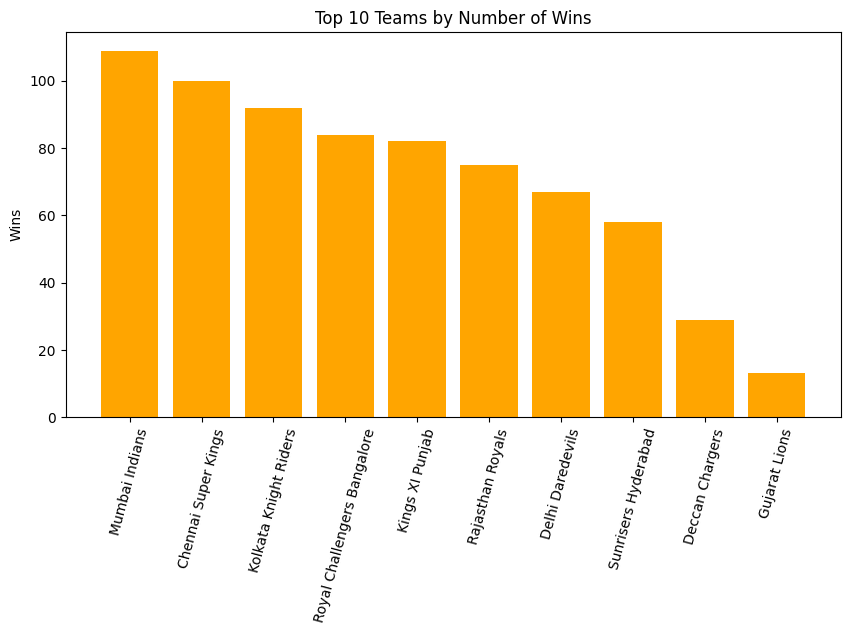

In [11]:
import matplotlib.pyplot as plt

top_winners = df['winner'].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.bar(top_winners.index, top_winners.values, color='orange')
plt.xticks(rotation=75)
plt.title('Top 10 Teams by Number of Wins')
plt.ylabel('Wins')
plt.show()


In [12]:
import joblib

joblib.dump(best_model, 'ipl_predictor_model.pkl')
joblib.dump(le_team1, 'le_team1.pkl')
joblib.dump(le_team2, 'le_team2.pkl')
joblib.dump(le_venue, 'le_venue.pkl')
joblib.dump(le_toss_winner, 'le_toss_winner.pkl')
joblib.dump(le_toss_decision, 'le_toss_decision.pkl')
joblib.dump(le_winner, 'le_winner.pkl')

print("Model and encoders saved!")

Model and encoders saved!


In [13]:
from google.colab import files
files.download('ipl_predictor_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>